In [45]:
import pandas as pd
import numpy as np


In [46]:
#!wget https://github.com/durveshcollegeid/sem5_ML/blob/main/sep04/adult.csv

In [47]:
path = "/content/adult.csv"

In [48]:
df = pd.read_csv( path )
df_backup = pd.read_csv( path )

In [49]:
col_list = [ "age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income" ]

In [50]:
df.columns = col_list
df_backup.columns = col_list

Drop unnecessary columns

In [51]:
df = df.drop( "fnlwgt", axis=1 )

OneHotEncoding

In [52]:
#targeted_cols = [ "workclass", "marital-status", "occupation", "relationship", "race", "sex", "native-country" ]
targeted_cols = [ "workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country" ]

In [53]:
df = pd.get_dummies(df, columns=targeted_cols, dtype=int)

Splitting into features and target

In [54]:
y = df[ "income" ]
X = df.drop( "income", axis=1 )

Splitting into test and train

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

Scaling Numeric data for X_train only

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
for col in X_train :
  if( X_train[col].dtype == "int64" or X_train[col].dtype == "float64" ) :
    scaler = StandardScaler()
    X_train[col] = scaler.fit_transform( np.array(X_train[col]).reshape(-1,1) )


Importing DecisionTreeClassifier model

In [59]:
from sklearn.tree import DecisionTreeClassifier

Instantiating the model without any arguments

In [71]:
dtc_model =  DecisionTreeClassifier(  )

Define a dictionary of chosen parameters for the knn model

In [72]:
dtc_params = {
    "criterion" : ["gini", "entropy", "log_loss"],
   #"splitter" : [ "best", "random" ],
  "max_depth" : [ 1, 2, 3, 4, 5, 6, 7, 8, 9, 10 ],
    #"min_samples_split" : [ 2, 3, 4, 5, 6, 7, 8, 9, 10 ],
    #"min_samples_leaf" : [ 1, 2, 3, 4, 5, 6, 7, 8, 9, 10 ],
    "max_features" : [ "sqrt", "log2" ],
}



Instantiating a cross-validator based on dictionary of chosen parameters

In [73]:
from sklearn.model_selection import GridSearchCV

In [75]:
dtc_grid = GridSearchCV( dtc_model, dtc_params, cv=5, scoring="accuracy", n_jobs=-1 )

Fit the cross validator on the training data

In [76]:
dtc_grid.fit( X_train, y_train )

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'max_features': ['sqrt', 'log2']},
             scoring='accuracy')

Obtain best parameters

In [77]:
print( f"Best parameters : { dtc_grid.best_params_ }" )

Best parameters : {'criterion': 'entropy', 'max_depth': 9, 'max_features': 'sqrt'}


In [78]:
print( f"Best CV score : { dtc_grid.best_score_ }" )

Best CV score : 0.8374534993877789


Use "best estimator" to predict labels on the test data

In [79]:
dtc_best = dtc_grid.best_estimator_

In [92]:
y_pred = dtc_best.predict( X_test )

Add pie chart to visualize performance

In [81]:
from sklearn.metrics import accuracy_score

In [93]:
dtc_acc = accuracy_score( y_test, y_pred )

In [89]:
import matplotlib.pyplot as plt

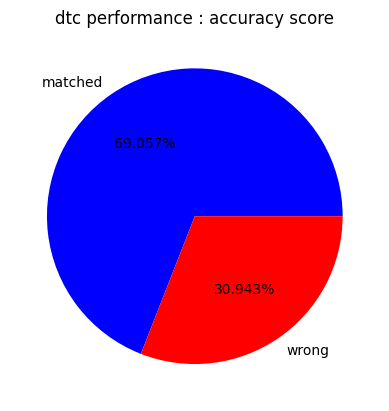

In [94]:
#plt.subplot( 1, 2, 1 )
plt.pie(
    x=[ dtc_acc*100, 100 - (dtc_acc)*100 ],
    labels=["matched", "wrong"],
    autopct='%1.3f%%',   # Formats the percentage to 1 decimal place
    colors=[ "blue", "red" ],       # Applies custom colors
    #pctdistance=0.85     # Adjusts the position of the percentage text
)
plt.title( "dtc performance : accuracy score" )

plt.show()
